# So sánh, lựa chọn và phân tích lỗi của SARIMAX, XGBoost và LSTM

## Mục đích

Notebook cung cấp bằng chứng cuối cùng cho việc lựa chọn mô hình. Cả ba candidate giải quyết cùng một bài toán hồi quy: dự đoán nồng độ PM2.5 đúng 24 giờ sau thời điểm phát hành t cho Hà Nội, TP.HCM và Đà Nẵng.

Ba họ mô hình được chọn vì các lý do bổ sung cho nhau:

- **SARIMAX** là baseline thống kê mùa vụ theo ngày, có tính diễn giải;
- **XGBoost** mô hình hóa tương tác phi tuyến giữa lịch sử ô nhiễm, thời tiết, thời gian, thành phố và bối cảnh OSM;
- **LSTM** học phụ thuộc thời gian từ chuỗi đa biến dài 48 giờ.

Mọi mô hình dùng cùng giao thức thời gian 70/15/15 và khoảng purge 24 giờ. Mô hình thắng được chọn nghiêm ngặt bằng **Validation RMSE**. Test chỉ được mở sau khi lựa chọn để báo cáo cuối, phân tích theo thành phố và phân tích lỗi. Quy tắc này ngăn rò rỉ Test và làm cho phép so sánh có thể bảo vệ về mặt khoa học.

Vì đây là hồi quy, RMSE và MAE là metric chính. Confusion matrix chỉ là chẩn đoán phụ, được tạo bằng cách chuyển dự đoán PM2.5 liên tục thành các dải nồng độ tham chiếu; đây không phải mô hình phân loại riêng và không phải dự báo AQI chính thức.


In [1]:
from dataclasses import dataclass
from datetime import datetime, timezone
from hashlib import sha256
from pathlib import Path
import json
import platform
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
from IPython.display import Markdown, display
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.casefold() == "models":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "models" / "results"
MODELS_DIR = PROJECT_ROOT / "models"
CANDIDATE_DIR = MODELS_DIR / "candidates"
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "pm25_training_data_enriched.csv"
CRAWL_MANIFEST_PATH = PROJECT_ROOT / "data" / "raw" / "crawl_manifest.json"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CANDIDATE_DIR.mkdir(parents=True, exist_ok=True)

from dataclasses import dataclass
import json
from typing import Any, Iterable

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)

HORIZON_HOURS = 24
POLLUTANT_FEATURES = ["pm25", "pm10", "o3", "no2", "so2", "co"]
WEATHER_FEATURES = [
    "temp", "humidity", "wind_speed", "wind_dir", "precip", "pressure", "cloud_cover",
]
TEMPORAL_FEATURES = ["hour", "day_of_week", "month", "is_weekend", "day_of_year"]
HISTORY_FEATURES = [
    "pm25_lag_1h", "pm25_lag_3h", "pm25_lag_6h", "pm25_lag_12h",
    "pm25_lag_24h", "pm25_lag_48h", "pm25_lag_72h", "pm25_lag_96h",
    "pm25_lag_120h", "pm25_lag_144h", "pm25_lag_168h",
    "pm25_roll_6h", "pm25_roll_12h", "pm25_roll_24h", "pm25_roll_72h",
    "pm25_roll_168h", "pm25_std_6h", "pm25_std_12h", "pm25_std_24h",
    "pm25_std_72h", "pm25_std_168h", "pm25_min_24h", "pm25_max_24h",
    "pm25_delta_1h", "pm25_delta_3h", "pm25_delta_24h",
    "pm25_roll_ratio_6h_24h", "pm25_roll_ratio_24h_72h",
    "pm25_same_hour_mean_7d", "pm25_same_hour_median_7d",
    "pm25_same_hour_std_7d", "pm25_same_hour_min_7d",
    "pm25_same_hour_max_7d", "pm25_same_hour_ratio_7d", "pm25_weekly_delta",
]
ENGINEERED_FEATURES = [
    "ventilation_index", "humid_stagnation", "rain_flag", "calm_wind",
    "high_humidity", "wind_x", "wind_y", "hour_sin", "hour_cos",
    "day_sin", "day_cos", "month_sin", "month_cos", "pm25_pm10_ratio",
    "no2_co_ratio",
]
SPATIAL_FEATURES = [
    "factories_2km", "factories_5km", "factories_10km",
    "factory_density_2km", "factory_density_5km", "factory_density_10km",
]
NUMERIC_FEATURES_FULL = (
    POLLUTANT_FEATURES
    + WEATHER_FEATURES
    + TEMPORAL_FEATURES
    + HISTORY_FEATURES
    + ENGINEERED_FEATURES
    + SPATIAL_FEATURES
)
CATEGORICAL_FEATURES = ["city", "season"]
PM25_BINS = [-np.inf, 9.0, 35.4, 55.4, 125.4, 225.4, np.inf]
PM25_LABELS = ["Good", "Moderate", "USG", "Unhealthy", "Very Unhealthy", "Hazardous"]


@dataclass(frozen=True)
class TemporalSplit:
    train_mask: pd.Series
    val_mask: pd.Series
    test_mask: pd.Series
    train_cut: pd.Timestamp
    val_cut: pd.Timestamp
    purge_hours: int

    def summary(self, frame: pd.DataFrame) -> dict[str, Any]:
        output: dict[str, Any] = {
            "strategy": "global chronological 70/15/15 split by target time with purge gaps",
            "train_cut": self.train_cut.isoformat(),
            "val_cut": self.val_cut.isoformat(),
            "purge_hours": self.purge_hours,
        }
        for name, mask in (
            ("train", self.train_mask),
            ("validation", self.val_mask),
            ("test", self.test_mask),
        ):
            part = frame.loc[mask]
            output[name] = {
                "rows": int(len(part)),
                "source_start": part["datetime"].min().isoformat(),
                "source_end": part["datetime"].max().isoformat(),
                "target_start": part["target_time"].min().isoformat(),
                "target_end": part["target_time"].max().isoformat(),
            }
        return output


def make_supervised_frame(df: pd.DataFrame, horizon_hours: int = HORIZON_HOURS) -> pd.DataFrame:
    frame = df.copy()
    frame["datetime"] = pd.to_datetime(frame["datetime"])
    frame = frame.sort_values(["city", "datetime"]).reset_index(drop=True)
    if frame.duplicated(["city", "datetime"]).any():
        raise ValueError("Duplicate city/datetime rows prevent exact t+24 target alignment.")

    frame["target_time"] = frame["datetime"] + pd.Timedelta(hours=horizon_hours)
    targets = frame[["city", "datetime", "pm25"]].rename(
        columns={"datetime": "target_time", "pm25": "target_pm25_24h"}
    )
    return frame.merge(targets, on=["city", "target_time"], how="left", validate="many_to_one")


def temporal_split(
    frame: pd.DataFrame,
    train_fraction: float = 0.70,
    validation_fraction: float = 0.15,
    purge_hours: int = HORIZON_HOURS,
) -> TemporalSplit:
    if train_fraction <= 0 or validation_fraction <= 0 or train_fraction + validation_fraction >= 1:
        raise ValueError("Temporal split must leave non-empty Train, Validation and Test sets.")
    unique_times = pd.Series(pd.to_datetime(frame["target_time"]).dropna().sort_values().unique())
    if len(unique_times) < 100:
        raise ValueError("Not enough target timestamps for a stable temporal split.")

    train_cut = pd.Timestamp(unique_times.iloc[int(len(unique_times) * train_fraction)])
    val_cut = pd.Timestamp(unique_times.iloc[int(len(unique_times) * (train_fraction + validation_fraction))])
    purge = pd.Timedelta(hours=purge_hours)
    target_time = pd.to_datetime(frame["target_time"])
    train_mask = target_time < train_cut
    val_mask = (target_time >= train_cut + purge) & (target_time < val_cut)
    test_mask = target_time >= val_cut + purge
    if not train_mask.any() or not val_mask.any() or not test_mask.any():
        raise ValueError("Temporal split produced an empty partition.")
    return TemporalSplit(train_mask, val_mask, test_mask, train_cut, val_cut, purge_hours)


def pm25_category(values: Any) -> pd.Series:
    array = np.asarray(values, dtype=float)
    return pd.Series(pd.cut(array, bins=PM25_BINS, labels=PM25_LABELS, include_lowest=True))


def regression_metrics(y_true: Any, y_pred: Any) -> dict[str, float]:
    actual = np.asarray(y_true, dtype=float)
    predicted = np.clip(np.asarray(y_pred, dtype=float), 0.0, None)
    return {
        "rmse_ug_m3": float(np.sqrt(mean_squared_error(actual, predicted))),
        "mae_ug_m3": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
        "bias_ug_m3": float(np.mean(predicted - actual)),
    }


def risk_metrics(y_true: Any, y_pred: Any) -> dict[str, float]:
    actual_category = pm25_category(y_true)
    predicted_category = pm25_category(np.clip(np.asarray(y_pred, dtype=float), 0.0, None))
    actual_usg = actual_category.isin(PM25_LABELS[2:]).to_numpy()
    predicted_usg = predicted_category.isin(PM25_LABELS[2:]).to_numpy()
    actual_unhealthy = actual_category.isin(PM25_LABELS[3:]).to_numpy()
    predicted_unhealthy = predicted_category.isin(PM25_LABELS[3:]).to_numpy()
    return {
        "bucket_accuracy": float(accuracy_score(actual_category, predicted_category)),
        "bucket_f1_macro": float(f1_score(
            actual_category, predicted_category, labels=PM25_LABELS,
            average="macro", zero_division=0,
        )),
        "usg_plus_recall": float(recall_score(actual_usg, predicted_usg, zero_division=0)),
        "usg_plus_precision": float(precision_score(actual_usg, predicted_usg, zero_division=0)),
        "unhealthy_plus_recall": float(recall_score(actual_unhealthy, predicted_unhealthy, zero_division=0)),
        "unhealthy_plus_precision": float(precision_score(actual_unhealthy, predicted_unhealthy, zero_division=0)),
    }


def all_metrics(y_true: Any, y_pred: Any) -> dict[str, float]:
    return {**regression_metrics(y_true, y_pred), **risk_metrics(y_true, y_pred)}


def metrics_by_city(frame: pd.DataFrame, predictions: Any) -> pd.DataFrame:
    scored = frame[["city", "target_pm25_24h"]].copy()
    scored["prediction_pm25"] = np.asarray(predictions, dtype=float)
    rows = []
    for city, city_frame in scored.groupby("city", sort=True):
        rows.append({
            "city": city,
            "rows": int(len(city_frame)),
            **all_metrics(city_frame["target_pm25_24h"], city_frame["prediction_pm25"]),
        })
    return pd.DataFrame(rows)


def build_feature_matrix(
    df: pd.DataFrame,
    feature_columns: Iterable[str] | None = None,
    numeric_features: list[str] | None = None,
    categorical_features: list[str] | None = None,
) -> pd.DataFrame:
    numeric = numeric_features or NUMERIC_FEATURES_FULL
    categorical = categorical_features or CATEGORICAL_FEATURES
    encoded = pd.get_dummies(
        df[numeric + categorical], columns=categorical, drop_first=False, dtype=float
    )
    if feature_columns is None:
        return encoded.astype(float)
    ordered_columns = list(feature_columns)
    for column in ordered_columns:
        if column not in encoded.columns:
            encoded[column] = 0.0
    return encoded.reindex(columns=ordered_columns, fill_value=0.0).astype(float)


RISK_STANDARD = {
    "name": "U.S. EPA 2024 PM2.5 reference bands",
    "scope": "Reference bands applied to an hourly PM2.5 forecast; not an official AQI value",
    "source": "https://aqs.epa.gov/aqsweb/documents/codetables/aqi_breakpoints.html",
    "breakpoints_ug_m3": [9.0, 35.4, 55.4, 125.4, 225.4],
}
MODEL_FILES = {
    "SARIMAX": {"slug": "sarimax", "artifacts": [CANDIDATE_DIR / "sarimax_t24_by_city.joblib"]},
    "XGBoost": {"slug": "xgboost", "artifacts": [CANDIDATE_DIR / "xgboost_t24.joblib"]},
    "LSTM": {
        "slug": "lstm",
        "artifacts": [
            CANDIDATE_DIR / "lstm_t24.keras",
            CANDIDATE_DIR / "lstm_t24_preprocessing.joblib",
        ],
    },
}


def prepare_training_data() -> tuple[pd.DataFrame, Any]:
    frame = pd.read_csv(DATA_PATH, low_memory=False)
    frame["datetime"] = pd.to_datetime(frame["datetime"])
    supervised = make_supervised_frame(frame, horizon_hours=HORIZON_HOURS)
    required = NUMERIC_FEATURES_FULL + CATEGORICAL_FEATURES + ["target_pm25_24h", "target_time"]
    model_frame = supervised.dropna(subset=required).copy().reset_index(drop=True)
    split = temporal_split(model_frame, purge_hours=HORIZON_HOURS)
    (RESULTS_DIR / "temporal_split.json").write_text(
        json.dumps(split.summary(model_frame), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return model_frame, split


def _required_paths() -> list[Path]:
    paths: list[Path] = []
    for config in MODEL_FILES.values():
        slug = str(config["slug"])
        paths.extend([
            RESULTS_DIR / f"{slug}_canonical_metrics.csv",
            RESULTS_DIR / f"{slug}_canonical_by_city.csv",
            RESULTS_DIR / f"{slug}_canonical_test_predictions.csv",
            *config["artifacts"],
        ])
    return paths


def validate_inputs() -> None:
    missing = [path.relative_to(PROJECT_ROOT) for path in _required_paths() if not path.exists()]
    if missing:
        formatted = "\n".join(f"- {path}" for path in missing)
        raise FileNotFoundError(
            "Hãy chạy ba notebook huấn luyện trước notebook lựa chọn. Còn thiếu:\n"
            f"{formatted}"
        )


def _save_classification_outputs(model: str, slug: str) -> None:
    predictions = pd.read_csv(
        RESULTS_DIR / f"{slug}_canonical_test_predictions.csv",
        parse_dates=["datetime", "target_time"],
    )
    actual_category = pm25_category(predictions["actual_pm25"]).astype(str)
    predicted_category = pm25_category(predictions["predicted_pm25"]).astype(str)
    matrix = pd.DataFrame(
        confusion_matrix(actual_category, predicted_category, labels=PM25_LABELS),
        index=PM25_LABELS,
        columns=PM25_LABELS,
    )
    matrix.index.name = "actual"
    matrix.to_csv(RESULTS_DIR / f"original_{slug}_confusion_matrix.csv", encoding="utf-8-sig")
    report = pd.DataFrame(classification_report(
        actual_category,
        predicted_category,
        labels=PM25_LABELS,
        output_dict=True,
        zero_division=0,
    )).transpose()
    report.to_csv(
        RESULTS_DIR / f"original_{slug}_classification_report.csv", encoding="utf-8-sig"
    )
    errors = predictions.copy()
    errors["model"] = model
    errors["actual_category"] = actual_category.to_numpy()
    errors["predicted_category"] = predicted_category.to_numpy()
    errors.nlargest(25, "abs_error_ug_m3").to_csv(
        RESULTS_DIR / f"original_{slug}_top_error_cases.csv",
        index=False,
        encoding="utf-8-sig",
    )


def evaluate_original_suite() -> pd.DataFrame:
    """Validate outputs and rank the three required models by Validation RMSE."""
    validate_inputs()
    metric_rows: list[pd.DataFrame] = []
    by_city_rows: list[pd.DataFrame] = []
    expected_cities = {"Hà Nội", "TP.HCM", "Đà Nẵng"}

    for expected_model, config in MODEL_FILES.items():
        slug = str(config["slug"])
        metrics = pd.read_csv(RESULTS_DIR / f"{slug}_canonical_metrics.csv")
        if len(metrics) != 1 or str(metrics.iloc[0]["model"]) != expected_model:
            raise ValueError(f"Metric artifact không hợp lệ đối với {expected_model}.")
        metric_rows.append(metrics)
        by_city = pd.read_csv(RESULTS_DIR / f"{slug}_canonical_by_city.csv")
        if set(by_city["city"]) != expected_cities:
            raise ValueError(f"{expected_model} chưa bao phủ đủ ba thành phố.")
        by_city_rows.append(by_city)
        _save_classification_outputs(expected_model, slug)

    comparison = pd.concat(metric_rows, ignore_index=True)
    comparison = comparison.sort_values("val_rmse_ug_m3").reset_index(drop=True)
    comparison.insert(0, "validation_rank", np.arange(1, len(comparison) + 1))
    comparison["val_generalization_gap_ug_m3"] = (
        comparison["val_rmse_ug_m3"] - comparison["train_rmse_ug_m3"]
    )
    comparison["val_generalization_gap_pct"] = np.where(
        comparison["train_rmse_ug_m3"].abs() > 1e-9,
        comparison["val_generalization_gap_ug_m3"] / comparison["train_rmse_ug_m3"] * 100.0,
        np.nan,
    )
    comparison["selected_within_original_suite"] = comparison.index == 0
    comparison["selection_metric"] = "Validation RMSE"
    comparison.to_csv(
        RESULTS_DIR / "original_model_suite_comparison.csv", index=False, encoding="utf-8-sig"
    )

    by_city_comparison = pd.concat(by_city_rows, ignore_index=True)
    by_city_comparison.to_csv(
        RESULTS_DIR / "original_model_suite_by_city.csv", index=False, encoding="utf-8-sig"
    )

    selected = comparison.iloc[0]
    selected_model = str(selected["model"])
    selection: dict[str, Any] = {
        "selected_model": selected_model,
        "selection_metric": "Validation RMSE",
        "selected_without_test_metrics": True,
        "validation_rank": int(selected["validation_rank"]),
        "validation_rmse_ug_m3": float(selected["val_rmse_ug_m3"]),
        "reported_test_metrics": {
            "rmse_ug_m3": float(selected["test_rmse_ug_m3"]),
            "mae_ug_m3": float(selected["test_mae_ug_m3"]),
            "r2": float(selected["test_r2"]),
        },
        "candidate_artifacts": [
            str(path.relative_to(PROJECT_ROOT)) for path in MODEL_FILES[selected_model]["artifacts"]
        ],
        "deployment_status": "Đã chọn candidate; chưa đóng gói artifact production.",
    }
    (RESULTS_DIR / "original_model_suite_selection.json").write_text(
        json.dumps(selection, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    return comparison


comparison = evaluate_original_suite()
by_city = pd.read_csv(RESULTS_DIR / "original_model_suite_by_city.csv")
selection = json.loads(
    (RESULTS_DIR / "original_model_suite_selection.json").read_text(encoding="utf-8")
)
selected_model = selection["selected_model"]
display(comparison[[
    "validation_rank", "model", "train_rmse_ug_m3", "val_rmse_ug_m3",
    "test_rmse_ug_m3", "test_mae_ug_m3", "test_r2",
]])
print("Mô hình được chọn bằng Validation RMSE:", selected_model)


,validation_rank,model,train_rmse_ug_m3,val_rmse_ug_m3,test_rmse_ug_m3,test_mae_ug_m3,test_r2
0,1,XGBoost,12.866314,18.155728,16.042271,10.285115,0.581186
1,2,SARIMAX,14.260489,18.553699,16.412677,10.337383,0.561623
2,3,LSTM,14.277377,18.620789,16.068418,10.379282,0.579820


Mô hình được chọn bằng Validation RMSE: XGBoost


## 1. Đưa mô hình được chọn vào artifact triển khai

Mô hình thắng trên Validation được đưa vào models/pm25_24h_best.joblib. Bước promotion ghi lại phiên bản, siêu tham số, feature schema, metadata của split và bằng chứng lựa chọn. Cell cũng kiểm tra mô hình được chọn khớp với metadata đã lưu trước khi API sử dụng artifact.


In [2]:
# Đóng gói candidate được chọn thành artifact production, không phụ thuộc backend.
MODEL_PATH = MODELS_DIR / "pm25_24h_best.joblib"
METADATA_PATH = MODELS_DIR / "pm25_24h_best_metadata.json"
CANDIDATE_PATH = CANDIDATE_DIR / "xgboost_t24.joblib"
SELECTION_PATH = RESULTS_DIR / "original_model_suite_selection.json"
MODEL_CARD_PATH = RESULTS_DIR / "model_card.json"


def to_jsonable(value: Any) -> Any:
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (pd.Timestamp, datetime)):
        return value.isoformat()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return [to_jsonable(item) for item in value.tolist()]
    if isinstance(value, dict):
        return {str(key): to_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(item) for item in value]
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    return value


def sha256_file(path: Path) -> str:
    digest = sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def latest_profiles(df: pd.DataFrame, numeric_features: list[str]) -> dict[str, dict[str, Any]]:
    profiles: dict[str, dict[str, Any]] = {}
    columns = ["datetime", "city", *numeric_features, *CATEGORICAL_FEATURES]
    for city, city_frame in df.sort_values(["city", "datetime"]).groupby("city", sort=True):
        row = city_frame.iloc[-1]
        profiles[str(city)] = {
            key: to_jsonable(row.get(key)) for key in columns if key in row.index
        }
    return profiles


def conformal_radius(y_true: Any, y_pred: Any, coverage: float) -> float:
    residuals = np.abs(np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float))
    if residuals.size == 0:
        raise ValueError("Calibration residuals are empty.")
    quantile_level = min(1.0, np.ceil((residuals.size + 1) * coverage) / residuals.size)
    return float(np.quantile(residuals, quantile_level, method="higher"))


def interval_metrics(y_true: Any, y_pred: Any, radius: float) -> dict[str, float]:
    actual = np.asarray(y_true, dtype=float)
    prediction = np.asarray(y_pred, dtype=float)
    lower = np.maximum(0.0, prediction - radius)
    upper = prediction + radius
    return {
        "coverage": float(np.mean((actual >= lower) & (actual <= upper))),
        "mean_width_ug_m3": float(np.mean(upper - lower)),
    }


def build_city_conditioned_intervals(
    frame: pd.DataFrame,
    split: TemporalSplit,
    val_prediction: np.ndarray,
    test_prediction: np.ndarray,
) -> dict[str, Any]:
    val_frame = frame.loc[split.val_mask, ["city", "target_pm25_24h"]].copy()
    test_frame = frame.loc[split.test_mask, ["city", "target_pm25_24h"]].copy()
    val_frame["prediction"] = np.asarray(val_prediction, dtype=float)
    test_frame["prediction"] = np.asarray(test_prediction, dtype=float)
    output: dict[str, Any] = {
        "method": "city-conditioned split conformal absolute residual",
        "calibration_set": "validation",
        "levels": {},
    }
    for coverage in (0.80, 0.90):
        global_radius = conformal_radius(
            val_frame["target_pm25_24h"], val_frame["prediction"], coverage
        )
        city_details: dict[str, Any] = {}
        all_actual, all_prediction, all_radius = [], [], []
        for city, city_val in val_frame.groupby("city", sort=True):
            radius = conformal_radius(
                city_val["target_pm25_24h"], city_val["prediction"], coverage
            )
            city_test = test_frame[test_frame["city"] == city]
            city_details[str(city)] = {
                "radius_ug_m3": radius,
                "calibration_rows": int(len(city_val)),
                "test_rows": int(len(city_test)),
                **interval_metrics(
                    city_test["target_pm25_24h"], city_test["prediction"], radius
                ),
            }
            all_actual.append(city_test["target_pm25_24h"].to_numpy(dtype=float))
            all_prediction.append(city_test["prediction"].to_numpy(dtype=float))
            all_radius.append(np.full(len(city_test), radius, dtype=float))
        actual = np.concatenate(all_actual)
        prediction = np.concatenate(all_prediction)
        radii = np.concatenate(all_radius)
        lower = np.maximum(0.0, prediction - radii)
        upper = prediction + radii
        output["levels"][str(int(coverage * 100))] = {
            "fallback_global_radius_ug_m3": global_radius,
            "by_city": city_details,
            "combined_test_coverage": float(np.mean((actual >= lower) & (actual <= upper))),
            "combined_mean_width_ug_m3": float(np.mean(upper - lower)),
        }
    return output


def promote() -> dict[str, Any]:
    selection = json.loads(SELECTION_PATH.read_text(encoding="utf-8"))
    if selection.get("selected_model") != "XGBoost":
        raise ValueError(
            "Notebook triển khai phẳng hiện hỗ trợ XGBoost; kết quả Validation hiện tại phải chọn XGBoost."
        )

    candidate = joblib.load(CANDIDATE_PATH)
    frame, split = prepare_training_data()
    matrix = build_feature_matrix(
        frame,
        feature_columns=candidate["feature_columns"],
        numeric_features=candidate["numeric_features"],
        categorical_features=candidate["categorical_features"],
    )
    predictions = {
        name: np.clip(
            candidate["model"].predict(matrix.loc[getattr(split, f"{name}_mask")]),
            0.0,
            None,
        )
        for name in ("train", "val", "test")
    }
    comparison = pd.read_csv(RESULTS_DIR / "original_model_suite_comparison.csv")
    selected = comparison.loc[comparison["model"] == "XGBoost"].iloc[0]
    interval = build_city_conditioned_intervals(
        frame, split, predictions["val"], predictions["test"]
    )
    metrics = {
        "model": "XGBoost",
        "scope": "All three cities",
        "horizon_hours": HORIZON_HOURS,
        "feature_set": str(selected["feature_set"]),
        "feature_count": len(candidate["feature_columns"]),
        "supervised_rows": int(len(frame)),
        "data_start_time": frame["datetime"].min().isoformat(),
        "data_end_time": frame["datetime"].max().isoformat(),
        "train_rmse_ug_m3": float(selected["train_rmse_ug_m3"]),
        "val_rmse_ug_m3": float(selected["val_rmse_ug_m3"]),
        "test_rmse_ug_m3": float(selected["test_rmse_ug_m3"]),
        "test_mae_ug_m3": float(selected["test_mae_ug_m3"]),
        "test_r2": float(selected["test_r2"]),
        "bucket_accuracy": float(selected["test_bucket_accuracy"]),
        "bucket_f1_macro": float(selected["test_bucket_f1_macro"]),
        "usg_plus_recall": float(selected["test_usg_plus_recall"]),
        "usg_plus_precision": float(selected["test_usg_plus_precision"]),
        "unhealthy_plus_recall": float(selected["test_unhealthy_plus_recall"]),
        "unhealthy_plus_precision": float(selected["test_unhealthy_plus_precision"]),
    }
    manifest = (
        json.loads(CRAWL_MANIFEST_PATH.read_text(encoding="utf-8"))
        if CRAWL_MANIFEST_PATH.exists()
        else {}
    )
    model_details = {
        "architecture": "XGBoost gradient-boosted regression trees",
        **to_jsonable(candidate["model"].get_params(deep=False)),
        "best_iteration": int(candidate.get("best_iteration", -1)),
    }
    artifact: dict[str, Any] = {
        "model": candidate["model"],
        "model_name": "XGBoost",
        "model_version": "3.0.0",
        "model_details": model_details,
        "feature_columns": list(candidate["feature_columns"]),
        "numeric_features": list(candidate["numeric_features"]),
        "categorical_features": list(candidate["categorical_features"]),
        "target": {
            "name": "target_pm25_24h",
            "definition": "PM2.5 concentration at exactly t + 24 hours",
            "unit": "ug/m3",
            "horizon_hours": HORIZON_HOURS,
        },
        "metrics": metrics,
        "interval": interval,
        "risk_standard": RISK_STANDARD,
        "split": split.summary(frame),
        "data": {
            "path": DATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "sha256": sha256_file(DATA_PATH),
            "crawl_run_id": manifest.get("run_id"),
            "crawl_created_at": manifest.get("created_at"),
            "coverage_statement": manifest.get("coverage_statement"),
        },
        "runtime": {
            "python": platform.python_version(),
            "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__,
            "xgboost": xgb.__version__,
        },
        "created_at": datetime.now(timezone.utc).isoformat(),
        "selection": {
            "primary_metric": "validation RMSE",
            "scope": "required SARIMAX/XGBoost/LSTM suite",
            "candidates": ["SARIMAX", "XGBoost", "LSTM"],
            "selected_without_test_metrics": True,
            "comparison_path": "models/results/original_model_suite_comparison.csv",
            "selection_path": "models/results/original_model_suite_selection.json",
            "validation_rmse_ug_m3": float(selection["validation_rmse_ug_m3"]),
        },
        "latest_profiles": latest_profiles(frame, list(candidate["numeric_features"])),
        "candidate_training": {
            "source_artifact": CANDIDATE_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "best_iteration": int(candidate.get("best_iteration", -1)),
            "params": candidate.get("params", {}),
        },
    }
    joblib.dump(artifact, MODEL_PATH)
    METADATA_PATH.write_text(
        json.dumps(
            to_jsonable({key: value for key, value in artifact.items() if key != "model"}),
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )

    prediction_frame = frame.loc[
        split.test_mask,
        ["datetime", "target_time", "city", "pm25", "wind_speed", "precip", "target_pm25_24h"],
    ].copy()
    prediction_frame.rename(columns={"target_pm25_24h": "actual_pm25"}, inplace=True)
    prediction_frame["predicted_pm25"] = predictions["test"]
    prediction_frame["abs_error_ug_m3"] = np.abs(
        prediction_frame["actual_pm25"] - prediction_frame["predicted_pm25"]
    )
    radius_by_city = {
        city: details["radius_ug_m3"]
        for city, details in interval["levels"]["90"]["by_city"].items()
    }
    prediction_frame["interval_90_radius"] = prediction_frame["city"].map(radius_by_city).astype(float)
    prediction_frame["interval_90_lower"] = np.maximum(
        0.0, prediction_frame["predicted_pm25"] - prediction_frame["interval_90_radius"]
    )
    prediction_frame["interval_90_upper"] = (
        prediction_frame["predicted_pm25"] + prediction_frame["interval_90_radius"]
    )
    prediction_frame.to_csv(
        RESULTS_DIR / "best_model_test_predictions.csv", index=False, encoding="utf-8-sig"
    )

    actual_category = pm25_category(prediction_frame["actual_pm25"])
    predicted_category = pm25_category(prediction_frame["predicted_pm25"])
    pd.DataFrame(
        confusion_matrix(actual_category, predicted_category, labels=PM25_LABELS),
        index=PM25_LABELS,
        columns=PM25_LABELS,
    ).to_csv(RESULTS_DIR / "best_model_confusion_matrix.csv", encoding="utf-8-sig")
    pd.DataFrame(classification_report(
        actual_category,
        predicted_category,
        labels=PM25_LABELS,
        output_dict=True,
        zero_division=0,
    )).transpose().to_csv(
        RESULTS_DIR / "best_model_classification_report.csv", encoding="utf-8-sig"
    )

    error_cases = prediction_frame.copy()
    error_cases["actual_category"] = actual_category.astype(str).to_numpy()
    error_cases["predicted_category"] = predicted_category.astype(str).to_numpy()
    error_cases["diagnostic_label"] = np.select(
        [
            error_cases["actual_pm25"] - error_cases["predicted_pm25"] >= 30.0,
            error_cases["predicted_pm25"] - error_cases["actual_pm25"] >= 30.0,
        ],
        ["missed_pollution_peak", "overpredicted_pollution"],
        default="transition_or_unobserved_driver",
    )
    error_cases.sort_values("abs_error_ug_m3", ascending=False).head(30).to_csv(
        RESULTS_DIR / "best_model_top_error_cases.csv", index=False, encoding="utf-8-sig"
    )

    importance = pd.DataFrame({
        "feature": candidate["feature_columns"],
        "importance": np.asarray(candidate["model"].feature_importances_, dtype=float),
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    importance.to_csv(
        RESULTS_DIR / "best_model_feature_importance.csv", index=False, encoding="utf-8-sig"
    )

    curve = pd.read_csv(RESULTS_DIR / "xgboost_canonical_learning_curve.csv")
    pd.DataFrame({
        "round": curve["round"],
        "train_rows": int(split.train_mask.sum()),
        "train_rmse_ug_m3": curve["train_rmse"],
        "val_rmse_ug_m3": curve["val_rmse"],
    }).to_csv(RESULTS_DIR / "best_model_learning_curve.csv", index=False)
    pd.DataFrame([metrics]).to_csv(
        RESULTS_DIR / "best_model_metrics.csv", index=False, encoding="utf-8-sig"
    )

    selection["deployment_status"] = "Đã đóng gói artifact production cho local webapp và cloud."
    selection["production_artifact"] = MODEL_PATH.relative_to(PROJECT_ROOT).as_posix()
    selection["model_version"] = artifact["model_version"]
    SELECTION_PATH.write_text(
        json.dumps(to_jsonable(selection), ensure_ascii=False, indent=2), encoding="utf-8"
    )

    model_card = {
        "model_name": artifact["model_name"],
        "model_version": artifact["model_version"],
        "intended_use": "24-hour-ahead PM2.5 concentration forecast for three representative Vietnamese city grid cells",
        "not_intended_for": [
            "Official regulatory AQI reporting",
            "District-level or street-level exposure estimates",
            "Medical diagnosis or individual treatment decisions",
        ],
        "target": artifact["target"],
        "model_details": artifact["model_details"],
        "data": artifact["data"],
        "split": artifact["split"],
        "metrics": metrics,
        "interval": interval,
        "risk_standard": RISK_STANDARD,
        "selection": artifact["selection"],
        "known_limitations": [
            "CAMS Global values are modelled grid data at approximately 45 km resolution.",
            "Abrupt local emission events are not directly observed by the available features.",
            "Reference health bands are applied to hourly concentrations and are not an official AQI calculation.",
        ],
    }
    MODEL_CARD_PATH.write_text(
        json.dumps(to_jsonable(model_card), ensure_ascii=False, indent=2), encoding="utf-8"
    )
    return artifact


promoted_artifact = promote()
selection = json.loads(SELECTION_PATH.read_text(encoding="utf-8"))
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
selected_model = selection["selected_model"]
print("Đã đóng gói:", promoted_artifact["model_name"], promoted_artifact["model_version"])
print("Artifact:", selection["production_artifact"])


Đã đóng gói: XGBoost 3.0.0
Artifact: models/pm25_24h_best.joblib


## 2. Phân tích cuối trên mô hình triển khai

Cell phân tích tái tạo dự đoán Test từ artifact đã lưu và kiểm tra RMSE khớp với metadata. Sau đó, notebook tạo khoảng tin cậy block bootstrap, độ phủ theo thành phố, thống kê feature drift, lỗi theo dải PM2.5 và chẩn đoán overfitting. Bootstrap theo ngày mục tiêu giữ được phụ thuộc thời gian tốt hơn so với lấy mẫu độc lập từng giờ.


In [3]:
# Phân tích cuối chỉ dùng artifact do notebook này vừa đóng gói.
def block_bootstrap_ci(predictions: pd.DataFrame, iterations: int = 600) -> pd.DataFrame:
    rng = np.random.default_rng(42)
    frame = predictions.copy()
    frame["target_date"] = pd.to_datetime(frame["target_time"]).dt.date
    blocks = [group for _, group in frame.groupby("target_date", sort=True)]
    estimates = []
    for _ in range(iterations):
        selected = rng.integers(0, len(blocks), size=len(blocks))
        actual = np.concatenate([
            blocks[index]["actual_pm25"].to_numpy(dtype=float) for index in selected
        ])
        predicted = np.concatenate([
            blocks[index]["predicted_pm25"].to_numpy(dtype=float) for index in selected
        ])
        estimates.append(regression_metrics(actual, predicted))
    estimate_frame = pd.DataFrame(estimates)
    point = regression_metrics(frame["actual_pm25"], frame["predicted_pm25"])
    return pd.DataFrame([
        {
            "metric": metric,
            "point_estimate": point[metric],
            "ci_95_lower": float(estimate_frame[metric].quantile(0.025)),
            "ci_95_upper": float(estimate_frame[metric].quantile(0.975)),
            "bootstrap_unit": "target day",
            "iterations": iterations,
        }
        for metric in ("rmse_ug_m3", "mae_ug_m3", "r2", "bias_ug_m3")
    ])


def analyze() -> dict[str, Any]:
    artifact = joblib.load(MODEL_PATH)
    frame, split = prepare_training_data()
    matrix = build_feature_matrix(
        frame,
        feature_columns=artifact["feature_columns"],
        numeric_features=artifact["numeric_features"],
        categorical_features=artifact["categorical_features"],
    )
    test_frame = frame.loc[split.test_mask].copy()
    test_prediction = np.clip(
        artifact["model"].predict(matrix.loc[split.test_mask]), 0.0, None
    )
    test_frame["prediction_pm25"] = test_prediction
    metrics = all_metrics(test_frame["target_pm25_24h"], test_prediction)
    if not np.isclose(
        metrics["rmse_ug_m3"], float(artifact["metrics"]["test_rmse_ug_m3"]), atol=1e-8
    ):
        raise RuntimeError("Artifact không tái tạo được Test RMSE đã ghi nhận.")

    predictions = pd.read_csv(
        RESULTS_DIR / "best_model_test_predictions.csv", encoding="utf-8-sig"
    )
    bootstrap = block_bootstrap_ci(predictions)
    bootstrap.to_csv(
        RESULTS_DIR / "best_model_bootstrap_ci.csv", index=False, encoding="utf-8-sig"
    )

    interval_rows = []
    for level, details in artifact["interval"]["levels"].items():
        for city, city_frame in test_frame.groupby("city", sort=True):
            radius = float(details["by_city"][str(city)]["radius_ug_m3"])
            interval_rows.append({
                "level": int(level),
                "city": city,
                "rows": int(len(city_frame)),
                "radius_ug_m3": radius,
                **interval_metrics(
                    city_frame["target_pm25_24h"], city_frame["prediction_pm25"], radius
                ),
            })
    pd.DataFrame(interval_rows).to_csv(
        RESULTS_DIR / "prediction_interval_coverage_by_city.csv",
        index=False,
        encoding="utf-8-sig",
    )

    scored = test_frame[
        ["datetime", "target_time", "city", "target_pm25_24h", "prediction_pm25"]
    ].copy()
    scored["actual_category"] = pm25_category(scored["target_pm25_24h"]).astype(str).to_numpy()
    scored["abs_error_ug_m3"] = np.abs(
        scored["target_pm25_24h"] - scored["prediction_pm25"]
    )
    error_by_band = (
        scored.groupby(["city", "actual_category"], observed=False)
        .agg(
            rows=("abs_error_ug_m3", "size"),
            mae_ug_m3=("abs_error_ug_m3", "mean"),
            median_abs_error_ug_m3=("abs_error_ug_m3", "median"),
            p90_abs_error_ug_m3=("abs_error_ug_m3", lambda values: values.quantile(0.90)),
        )
        .reset_index()
    )
    error_by_band.to_csv(
        RESULTS_DIR / "best_model_error_by_band.csv", index=False, encoding="utf-8-sig"
    )

    drift_rows = []
    for feature in artifact["numeric_features"]:
        train_values = frame.loc[split.train_mask, feature].astype(float)
        test_values = frame.loc[split.test_mask, feature].astype(float)
        pooled_std = float(np.sqrt((train_values.var() + test_values.var()) / 2.0))
        drift_rows.append({
            "feature": feature,
            "train_mean": float(train_values.mean()),
            "test_mean": float(test_values.mean()),
            "train_std": float(train_values.std()),
            "test_std": float(test_values.std()),
            "standardized_mean_difference": (
                float((test_values.mean() - train_values.mean()) / pooled_std)
                if pooled_std > 1e-12
                else 0.0
            ),
        })
    drift = pd.DataFrame(drift_rows).sort_values(
        "standardized_mean_difference", key=lambda values: values.abs(), ascending=False
    )
    drift.to_csv(
        RESULTS_DIR / "feature_drift_train_test.csv", index=False, encoding="utf-8-sig"
    )

    comparison = pd.read_csv(
        RESULTS_DIR / "original_model_suite_comparison.csv", encoding="utf-8-sig"
    )
    selected = comparison.loc[comparison["model"] == artifact["model_name"]].iloc[0]
    baseline = comparison.loc[comparison["model"] == "SARIMAX"].iloc[0]
    overfit = comparison[
        ["model", "train_rmse_ug_m3", "val_rmse_ug_m3", "test_rmse_ug_m3"]
    ].copy()
    overfit["train_val_gap_ug_m3"] = (
        overfit["val_rmse_ug_m3"] - overfit["train_rmse_ug_m3"]
    )
    overfit["diagnosis"] = np.where(
        overfit["train_val_gap_ug_m3"] > 5.0,
        "clear_overfitting",
        np.where(
            overfit["train_val_gap_ug_m3"] > 2.0,
            "moderate_overfitting",
            "limited_gap",
        ),
    )
    overfit.to_csv(
        RESULTS_DIR / "overfit_underfit_analysis.csv", index=False, encoding="utf-8-sig"
    )

    analysis = {
        "selected_model": artifact["model_name"],
        "selection_basis": artifact["selection"],
        "test_metrics_reproduced": metrics,
        "test_rmse_improvement_vs_sarimax_pct": float(
            (baseline["test_rmse_ug_m3"] - selected["test_rmse_ug_m3"])
            / baseline["test_rmse_ug_m3"]
            * 100.0
        ),
        "conformal_90_test_coverage": artifact["interval"]["levels"]["90"][
            "combined_test_coverage"
        ],
        "largest_drift_features": drift.head(10).to_dict(orient="records"),
        "bootstrap_ci": bootstrap.to_dict(orient="records"),
    }
    (RESULTS_DIR / "final_model_analysis.json").write_text(
        json.dumps(to_jsonable(analysis), ensure_ascii=False, indent=2), encoding="utf-8"
    )
    return analysis


final_analysis = analyze()
display(final_analysis)


{'selected_model': 'XGBoost',
 'selection_basis': {'primary_metric': 'validation RMSE',
  'scope': 'required SARIMAX/XGBoost/LSTM suite',
  'candidates': ['SARIMAX', 'XGBoost', 'LSTM'],
  'selected_without_test_metrics': True,
  'comparison_path': 'models/results/original_model_suite_comparison.csv',
  'selection_path': 'models/results/original_model_suite_selection.json',
  'validation_rmse_ug_m3': 18.155728033471178},
 'test_metrics_reproduced': {'rmse_ug_m3': 16.042270822243232,
  'mae_ug_m3': 10.285114813172548,
  'r2': 0.5811863616973488,
  'bias_ug_m3': 0.25381221315160546,
  'bucket_accuracy': 0.7226650316779072,
  'bucket_f1_macro': 0.3070754019923323,
  'usg_plus_recall': 0.7596993210475267,
  'usg_plus_precision': 0.6799045138888888,
  'unhealthy_plus_recall': 0.5846072746441751,
  'unhealthy_plus_precision': 0.6905354919053549},
 'test_rmse_improvement_vs_sarimax_pct': 2.2568294959940522,
 'conformal_90_test_coverage': 0.9267661284828667,
 'largest_drift_features': [{'featur

## 3. So sánh định lượng giữa các mô hình

**Bảng 1. Hiệu năng của ba mô hình bắt buộc trên cùng temporal split; RMSE và MAE có đơn vị ug/m^3, giá trị thấp hơn là tốt hơn.**


In [4]:
# Luôn đọc lại selection sau promotion để tránh dùng dictionary cũ trong kernel.
selection = json.loads(
    (RESULTS_DIR / "original_model_suite_selection.json").read_text(encoding="utf-8")
)
metadata = json.loads(
    (MODELS_DIR / "pm25_24h_best_metadata.json").read_text(encoding="utf-8")
)
selected_model = selection["selected_model"]

columns = [
    "validation_rank", "model", "train_rmse_ug_m3", "val_rmse_ug_m3",
    "test_rmse_ug_m3", "test_mae_ug_m3", "test_r2",
    "val_generalization_gap_ug_m3", "val_generalization_gap_pct",
    "selected_within_original_suite",
]
display(comparison[columns].sort_values("validation_rank"))
print(f"Mô hình được chọn: {selected_model}")
print(f"Artifact triển khai: {selection['production_artifact']}")
print(f"Phiên bản mô hình API: {selection['model_version']}")
print(selection["deployment_status"])

,validation_rank,model,train_rmse_ug_m3,val_rmse_ug_m3,test_rmse_ug_m3,test_mae_ug_m3,test_r2,val_generalization_gap_ug_m3,val_generalization_gap_pct,selected_within_original_suite
0,1,XGBoost,12.866314,18.155728,16.042271,10.285115,0.581186,5.289414,41.110559,True
1,2,SARIMAX,14.260489,18.553699,16.412677,10.337383,0.561623,4.293210,30.105631,False
2,3,LSTM,14.277377,18.620789,16.068418,10.379282,0.579820,4.343412,30.421637,False


Mô hình được chọn: XGBoost
Artifact triển khai: models/pm25_24h_best.joblib
Phiên bản mô hình API: 3.0.0
Đã đóng gói artifact production cho local webapp và cloud.


XGBoost có Validation RMSE thấp nhất, 18,156 ug/m^3, trong ba mô hình bắt buộc và vì vậy được chọn làm phiên bản 3.0.0. Khoảng cách Train-Validation RMSE là 5,29 ug/m^3, tương đương 41,1% Train RMSE. Khoảng cách này là bằng chứng overfitting, không thể kết luận bài toán tổng quát hóa đã được giải quyết hoàn toàn.

Quyết định lựa chọn vẫn hợp lệ vì XGBoost có Validation RMSE tốt nhất trong giao thức chung. Early stopping hạn chế suy giảm thêm nhưng không xóa khoảng cách tổng quát hóa. Kết luận đúng là XGBoost tổng quát hóa tốt hơn hai mô hình bắt buộc còn lại trên giai đoạn Validation hiện có, chứ không phải mô hình không overfit.


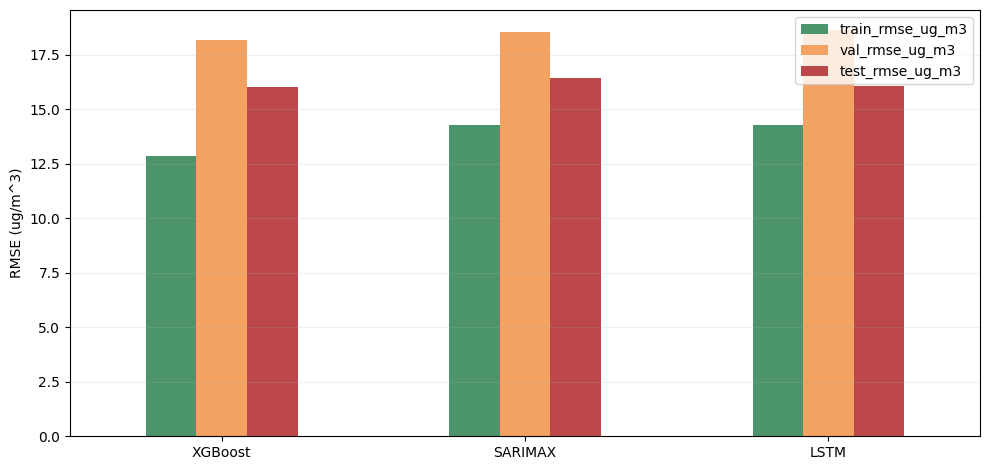

In [5]:
plot_frame = comparison.sort_values("validation_rank").set_index("model")
axis = plot_frame[["train_rmse_ug_m3", "val_rmse_ug_m3", "test_rmse_ug_m3"]].plot(
    kind="bar", figsize=(10, 4.8), color=["#4c956c", "#f4a261", "#bc4749"]
)
axis.set_ylabel("RMSE (ug/m^3)")
axis.set_xlabel("")
axis.tick_params(axis="x", rotation=0)
axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

*Hình 1. Train, Validation và Test RMSE của SARIMAX, XGBoost và LSTM trên cùng split; giá trị thấp hơn là tốt hơn, đơn vị ug/m^3.*


## 4. Độ ổn định theo khu vực

**Bảng 2. Hiệu năng Test theo thành phố của từng candidate; RMSE và MAE có đơn vị ug/m^3.**


In [6]:
city_columns = ["model", "city", "rows", "rmse_ug_m3", "mae_ug_m3", "r2", "bucket_f1_macro"]
display(by_city[city_columns].sort_values(["model", "rmse_ug_m3"]))

,model,city,rows,rmse_ug_m3,mae_ug_m3,r2,bucket_f1_macro
8,LSTM,Đà Nẵng,4893,7.703982,5.201392,0.419545,0.204908
7,LSTM,TP.HCM,4893,10.493073,7.754617,0.300503,0.209794
6,LSTM,Hà Nội,4893,24.599313,18.181837,0.393297,0.269995
2,SARIMAX,Đà Nẵng,4893,7.251062,4.936282,0.485789,0.278212
1,SARIMAX,TP.HCM,4893,10.660409,7.595565,0.278015,0.199080
0,SARIMAX,Hà Nội,4893,25.335857,18.480302,0.356421,0.254687
5,XGBoost,Đà Nẵng,4893,7.278234,5.242403,0.481928,0.269976
4,XGBoost,TP.HCM,4893,10.433804,7.382136,0.308382,0.209172
3,XGBoost,Hà Nội,4893,24.702761,18.230806,0.388183,0.260752


Hà Nội là thành phố khó nhất đối với XGBoost: Test RMSE bằng 24,70 ug/m^3, so với 10,43 ở TP.HCM và 7,28 ở Đà Nẵng. Khác biệt này phù hợp với phương sai cao hơn và tần suất đỉnh ô nhiễm nhiều hơn tại Hà Nội. Một điểm tổng hợp duy nhất sẽ che giấu failure mode địa lý quan trọng này.

Kết quả cũng giới hạn phạm vi khẳng định về khả năng tổng quát hóa. Mô hình được chọn tốt nhất về trung bình nhưng độ tin cậy không đồng đều giữa các thành phố và dải nồng độ.


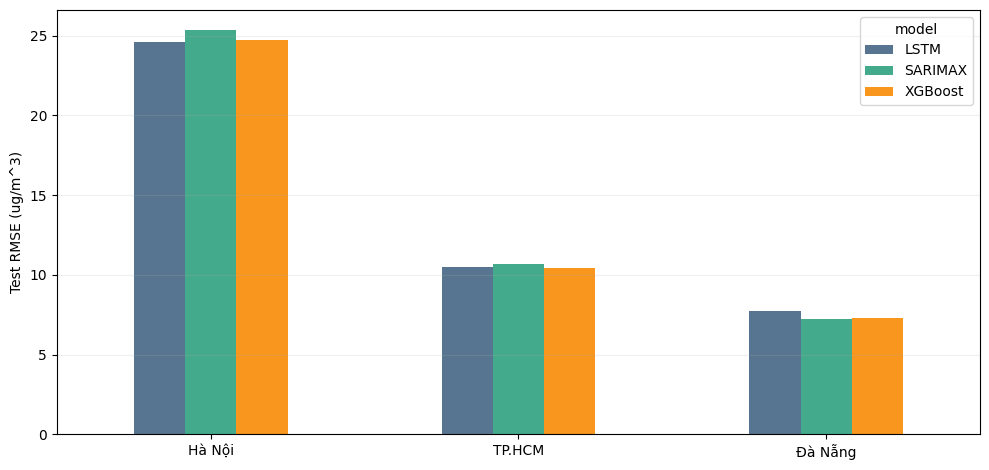

In [7]:
pivot = by_city.pivot(index="city", columns="model", values="rmse_ug_m3")
axis = pivot.plot(kind="bar", figsize=(10, 4.8), color=["#577590", "#43aa8b", "#f8961e"])
axis.set_ylabel("Test RMSE (ug/m^3)")
axis.set_xlabel("")
axis.tick_params(axis="x", rotation=0)
axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

*Hình 2. Test RMSE theo thành phố và mô hình; Hà Nội đóng góp phần lớn nhất vào sai số tổng hợp của mô hình được chọn.*


## 5. Chẩn đoán tối ưu của SARIMAX

**Bảng 3. Trạng thái hội tụ và tối ưu SARIMAX theo thành phố; AIC không có đơn vị và iteration là số bước optimizer.**


In [8]:
sarimax_fit = pd.read_csv(RESULTS_DIR / "sarimax_canonical_fit_summary.csv")
display(sarimax_fit)

,city,order,seasonal_order,aic,converged,converged_initial_fit,retry_used,initial_iterations,retry_iterations,iterations
0,Hà Nội,"(0, 0, 0)","(1, 0, 0, 24)",205017.011804,True,True,False,86,0,86
1,TP.HCM,"(0, 0, 0)","(1, 0, 0, 24)",171438.509412,True,False,True,100,1,101
2,Đà Nẵng,"(0, 0, 0)","(1, 0, 0, 24)",157744.097685,True,True,False,64,0,64


Lần fit SARIMAX đầu tiên cho TP.HCM chạm giới hạn 100 vòng trước khi L-BFGS xác nhận hội tụ. Warm-start từ tham số vòng 100 hội tụ sau một vòng bổ sung, tổng cộng 101 vòng. Hà Nội và Đà Nẵng hội tụ sau 86 và 64 vòng.

AIC chỉ thay đổi từ 171438,5096 thành 171438,5094 và metric tổng hợp gần như không đổi. Điều này cho thấy nghiệm đầu đã sát tối ưu, nhưng retry loại bỏ sự mơ hồ về estimator cuối. Artifact SARIMAX cuối chứa kết quả đã hội tụ cho cả ba thành phố.


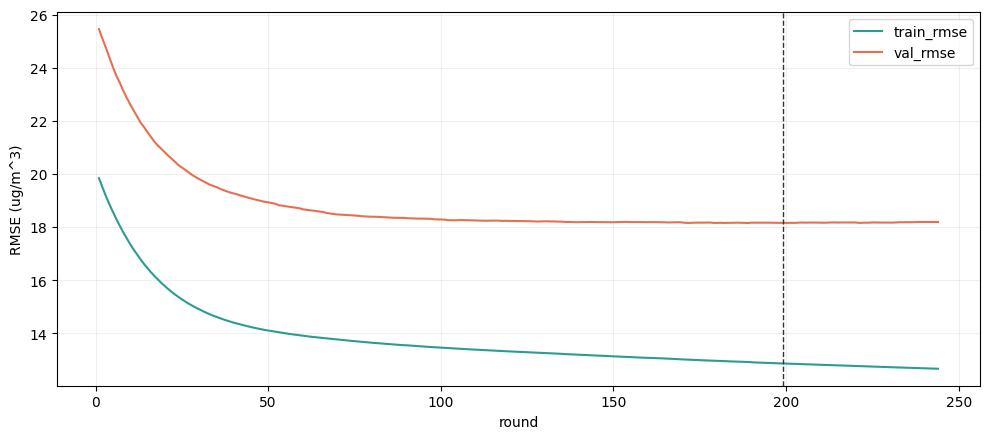

In [9]:
curve = pd.read_csv(RESULTS_DIR / "xgboost_canonical_learning_curve.csv")
axis = curve.plot(x="round", y=["train_rmse", "val_rmse"], figsize=(10, 4.5), color=["#2a9d8f", "#e76f51"])
axis.axvline(199, color="#333333", linestyle="--", linewidth=1)
axis.set_ylabel("RMSE (ug/m^3)")
axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Chẩn đoán learning curve của XGBoost

*Hình 3. Train RMSE và Validation RMSE của XGBoost theo boosting round; Validation RMSE đạt cực tiểu tại vòng 199.*


XGBoost hội tụ nhanh trong các boosting round đầu. Validation RMSE đạt 18,156 ug/m^3 tại vòng 199. Từ vòng 199 đến 244, Train RMSE giảm từ 12,866 xuống 12,667, trong khi Validation RMSE tăng lên 18,193. Sự phân kỳ xác nhận overfitting tiếp diễn sau vòng được chọn và chứng minh early stopping là cần thiết.

Hai đường không cần trùng nhau. Ép chúng trùng bằng regularization quá mạnh có thể làm cả hai sai số tăng. Tiêu chí phù hợp là Validation error thấp nhất trên giai đoạn chưa thấy, đồng thời báo cáo trung thực khoảng cách tổng quát hóa còn lại.


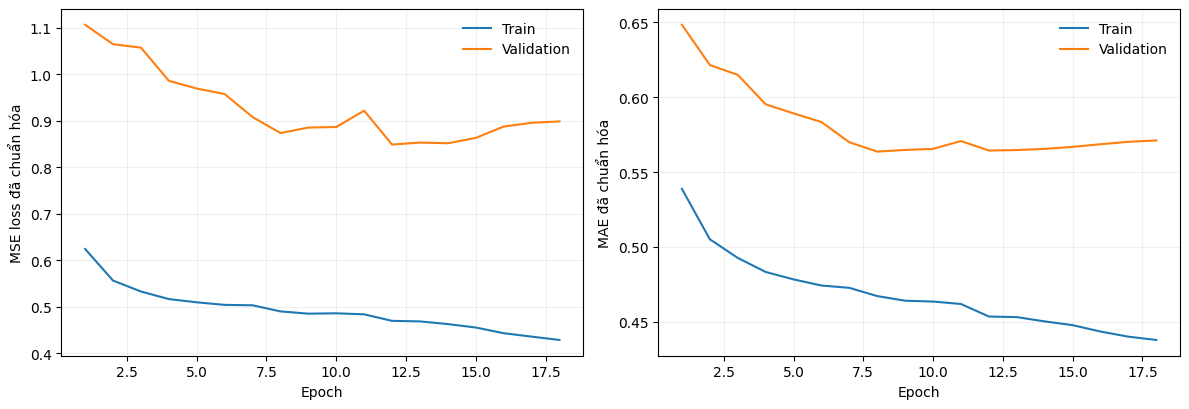

In [10]:
history = pd.read_csv(RESULTS_DIR / "lstm_canonical_training_history.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(history["epoch"], history["loss"], label="Train")
axes[0].plot(history["epoch"], history["val_loss"], label="Validation")
axes[0].set_ylabel("MSE loss đã chuẩn hóa")
axes[1].plot(history["epoch"], history["mae"], label="Train")
axes[1].plot(history["epoch"], history["val_mae"], label="Validation")
axes[1].set_ylabel("MAE đã chuẩn hóa")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.2)
    axis.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. Chẩn đoán learning curve của LSTM

*Hình 4. MSE và MAE của Train/Validation LSTM trong 18 epoch; giá trị nằm trong không gian target chuẩn hóa.*


Train loss của LSTM giảm trong suốt quá trình, nhưng Validation loss đạt cực tiểu 0,849 tại epoch 12 rồi tăng lên 0,899 ở epoch 18. Chuyển động ngược chiều giữa Train và Validation cho thấy overfitting sau epoch 12.

Early Stopping khôi phục trọng số epoch 12, còn ReduceLROnPlateau giảm learning rate. Các callback hoạt động đúng mục đích. Mô hình không underfit vì Train loss vẫn tiếp tục cải thiện; vấn đề chính là khoảng cách tổng quát hóa sau cực tiểu Validation.


## 8. Phân loại chẩn đoán theo dải PM2.5

**Bảng 4. Classification report khi ánh xạ đầu ra hồi quy XGBoost sang các dải PM2.5 tham chiếu; Precision, Recall và F1 không có đơn vị.**


In [11]:
report = pd.read_csv(RESULTS_DIR / "original_xgboost_classification_report.csv", index_col=0)
display(report)

,precision,recall,f1-score,support
Good,0.000000,0.000000,0.000000,551.000000
Moderate,0.850462,0.856158,0.853300,10004.000000
USG,0.362758,0.488999,0.416523,2227.000000
Unhealthy,0.594022,0.552723,0.572629,1726.000000
Very Unhealthy,0.000000,0.000000,0.000000,171.000000
Hazardous,0.000000,0.000000,0.000000,0.000000
accuracy,0.722665,0.722665,0.722665,0.722665
macro avg,0.301207,0.316313,0.307075,14679.000000
weighted avg,0.704487,0.722665,0.712063,14679.000000


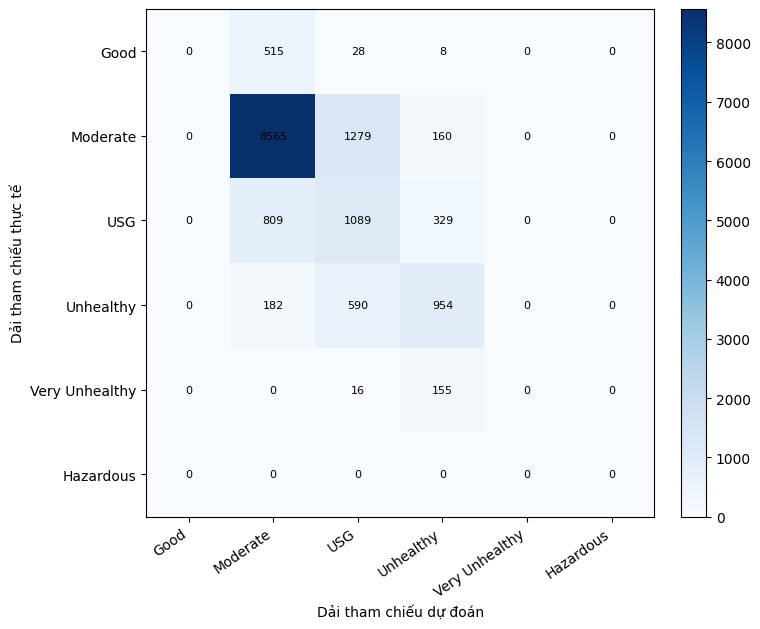

In [12]:
matrix = pd.read_csv(RESULTS_DIR / "original_xgboost_confusion_matrix.csv", index_col=0)
fig, axis = plt.subplots(figsize=(8, 6.4))
image = axis.imshow(matrix.to_numpy(), cmap="Blues")
axis.set_xticks(np.arange(len(matrix.columns)), matrix.columns, rotation=35, ha="right")
axis.set_yticks(np.arange(len(matrix.index)), matrix.index)
axis.set_xlabel("Dải tham chiếu dự đoán")
axis.set_ylabel("Dải tham chiếu thực tế")
for row in range(matrix.shape[0]):
    for col in range(matrix.shape[1]):
        axis.text(col, row, int(matrix.iloc[row, col]), ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

*Hình 5. Confusion matrix của XGBoost trên Test sau khi chuyển dự đoán PM2.5 liên tục sang dải tham chiếu; đây không phải phân loại AQI chính thức.*


Macro F1 chỉ đạt 0,307. Recall bằng 0 ở cả hai dải Good và Very Unhealthy vì mô hình hồi quy tập trung dự đoán vào các dải giữa chiếm đa số. Confusion matrix đáp ứng mục tiêu chẩn đoán của yêu cầu môn học nhưng không chứng minh khả năng nhận diện đáng tin cậy các điều kiện cực đoan.

Điểm yếu này một phần do mất cân bằng lớp sau khi rời rạc hóa, một phần do xu hướng hồi quy về trung bình. Regression RMSE vẫn là metric lựa chọn chính; recall ở dải cực đoan phải được báo cáo như một hạn chế.


## 9. Phân tích các trường hợp dự đoán sai

**Bảng 5. Các lỗi tuyệt đối lớn nhất của XGBoost trên Test; PM2.5 thực tế, PM2.5 dự đoán và sai số tuyệt đối có đơn vị ug/m^3.**


In [13]:
errors = pd.read_csv(RESULTS_DIR / "original_xgboost_top_error_cases.csv")
display(errors[["city", "datetime", "target_time", "actual_pm25", "predicted_pm25", "abs_error_ug_m3", "actual_category", "predicted_category"]].head(15))

,city,datetime,target_time,actual_pm25,predicted_pm25,abs_error_ug_m3,actual_category,predicted_category
0,Hà Nội,2026-04-24 06:00:00,2026-04-25 06:00:00,186.7,51.397312,135.302688,Very Unhealthy,USG
1,Hà Nội,2026-04-24 05:00:00,2026-04-25 05:00:00,181.6,52.837860,128.762140,Very Unhealthy,USG
2,Hà Nội,2026-04-24 04:00:00,2026-04-25 04:00:00,173.7,58.903866,114.796134,Very Unhealthy,Unhealthy
3,Hà Nội,2026-04-24 03:00:00,2026-04-25 03:00:00,170.9,60.940941,109.959059,Very Unhealthy,Unhealthy
4,Hà Nội,2026-04-23 01:00:00,2026-04-24 01:00:00,151.3,42.581139,108.718861,Very Unhealthy,USG
5,Hà Nội,2026-04-24 02:00:00,2026-04-25 02:00:00,164.8,56.526066,108.273934,Very Unhealthy,Unhealthy
6,Hà Nội,2026-04-02 19:00:00,2026-04-03 19:00:00,167.2,59.535217,107.664783,Very Unhealthy,Unhealthy
7,Hà Nội,2026-04-23 02:00:00,2026-04-24 02:00:00,144.8,39.819530,104.980470,Very Unhealthy,USG
8,Hà Nội,2025-12-10 23:00:00,2025-12-11 23:00:00,168.1,63.199726,104.900274,Very Unhealthy,Unhealthy
9,Hà Nội,2026-04-24 07:00:00,2026-04-25 07:00:00,155.1,51.962421,103.137579,Very Unhealthy,USG


Sai số tuyệt đối lớn nhất xấp xỉ 135,3 ug/m^3 và xuất hiện tại Hà Nội. Nhiều trường hợp sai trên 100 ug/m^3 vì các đỉnh ô nhiễm đột ngột không được biểu diễn tốt bởi CAMS dạng lưới, thời tiết, lịch sử và feature OSM tĩnh. Hồi quy bình phương sai số cũng có xu hướng làm trơn cực trị hiếm khi các quan sát dải giữa chiếm ưu thế trong Train.

Các lỗi này xác định giới hạn vận hành của hệ thống. Sản phẩm phù hợp như công cụ tham khảo dự báo 24 giờ, nhưng không nên được xem là hệ thống cảnh báo khẩn cấp hoặc công cụ pháp quy nếu chưa có dữ liệu trạm mặt đất dày hơn, mô hình hóa extreme event tốt hơn và giám sát thực tế.


## 10. Kết luận cuối và tài liệu tham khảo

XGBoost được chọn vì đạt Validation RMSE thấp nhất trong giao thức chung có kiểm soát rò rỉ. Test RMSE và MAE hỗ trợ đánh giá quyết định nhưng không tham gia lựa chọn. Mô hình vẫn có khoảng cách Train-Validation đáng kể, recall yếu ở các dải PM2.5 cực đoan và hiệu năng kém hơn rõ rệt tại Hà Nội. Các hạn chế này phải được trình bày cùng metric chính.

### Đối chiếu yêu cầu ml-model

**Bảng 6. Minh chứng đáp ứng từng yêu cầu trong ml-model.pdf.**

| Yêu cầu | Minh chứng trong các notebook chính |
|---|---|
| Giới thiệu bài toán | định nghĩa hồi quy PM2.5 đúng tại t+24h trong notebook 0-4 |
| Chia Train/Validation/Test | split thời gian 70/15/15, số dòng, thời gian và purge 24 giờ |
| Tiền xử lý | kiểm tra dữ liệu, miền vật lý, dữ liệu thiếu, nội suy, scaling, encoding và causal features |
| Ít nhất ba mô hình | SARIMAX, XGBoost và LSTM được huấn luyện, đánh giá trên cùng split |
| Kiến trúc deep learning | sơ đồ LSTM, layer, activation và 18.945 trainable parameters |
| Cấu hình huấn luyện | loss, optimizer, learning rate, callback, epoch, batch size, regularization và phương pháp tuning |
| Learning curve | XGBoost RMSE theo round và LSTM MSE/MAE theo epoch, có nhận xét |
| Đánh giá Test | RMSE, MAE, R2, metric theo thành phố, classification report và confusion matrix |
| Overfitting và phân tích lỗi | khoảng cách Train-Validation, callback, lỗi cực đoan và top error cases |
| So sánh và lựa chọn | xếp hạng theo Validation RMSE và quy tắc promotion không dùng Test |

### Tài liệu tham khảo

1. Chen, T. và Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD. https://doi.org/10.1145/2939672.2939785
2. Hochreiter, S. và Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735
3. Box, G. E. P., Jenkins, G. M., Reinsel, G. C. và Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (ấn bản thứ 5). Wiley.
4. Open-Meteo. *Air Quality API documentation*. https://open-meteo.com/en/docs/air-quality-api
5. Copernicus Atmosphere Monitoring Service. *CAMS global atmospheric composition forecasts*. https://atmosphere.copernicus.eu/
6. OpenStreetMap contributors. *OpenStreetMap data and copyright*. https://www.openstreetmap.org/copyright
